In [1]:
from src.data.bayesian_b_updater import BayesianGRBUpdater# %%
import src
from src.data.preparation import prepare_data_tpp
from config.config_loader import load_args_from_yaml 

In [2]:
args= load_args_from_yaml("../config/mixer_tpp.yaml")
args.dataset = 'SCEDC'
base_dir = f"../data/{args.dataset}"
# %%
seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Processed B_range: [0.0001, 0.01]
Using catalog dataset class: <class 'src.catalogs.scedc.SCEDC'>
Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/SCEDC/raw.
Number of training events: 78087
Number of validation events: 22928
Splitting into minibatches


/root/autodl-tmp/chuandian_eq/src/data/sequence.py:182: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


  0%|          | 0/260 [00:00<?, ?it/s]

[split_sequence] Window duration: 1488.9198
[split_sequence] Window duration: 1517.0160
[split_sequence] Window duration: 1545.1121
[split_sequence] Window duration: 1573.2083
[split_sequence] Window duration: 1601.3044
[split_sequence] Window duration: 1629.4006
[split_sequence] Window duration: 1657.4967
[split_sequence] Window duration: 1685.5929
[split_sequence] Window duration: 1713.6890
[split_sequence] Window duration: 1741.7852
[split_sequence] Window duration: 1769.8814
[split_sequence] Window duration: 1797.9775
[split_sequence] Window duration: 1826.0737
[split_sequence] Window duration: 1854.1698
[split_sequence] Window duration: 1882.2660
[split_sequence] Window duration: 1910.3621
[split_sequence] Window duration: 1938.4583
[split_sequence] Window duration: 1966.5544
[split_sequence] Window duration: 1994.6506
[split_sequence] Window duration: 2022.7467
[split_sequence] Window duration: 2050.8429
[split_sequence] Window duration: 2078.9390
[split_sequence] Window duration

  0%|          | 0/76 [00:00<?, ?it/s]

[split_sequence] Window duration: 4583.2432
[split_sequence] Window duration: 4625.5210
[split_sequence] Window duration: 4666.9546
[split_sequence] Window duration: 4707.4810
[split_sequence] Window duration: 4748.9175
[split_sequence] Window duration: 4788.5845
[split_sequence] Window duration: 4829.4946
[split_sequence] Window duration: 4871.0347
[split_sequence] Window duration: 4912.8433
[split_sequence] Window duration: 4953.1201
[split_sequence] Window duration: 4994.4482
[split_sequence] Window duration: 5034.5127
[split_sequence] Window duration: 5074.0596
[split_sequence] Window duration: 5114.4248
[split_sequence] Window duration: 5155.3774
[split_sequence] Window duration: 5195.0024
[split_sequence] Window duration: 5234.6084
[split_sequence] Window duration: 5275.0630
[split_sequence] Window duration: 5315.5508
[split_sequence] Window duration: 5355.2383
[split_sequence] Window duration: 5395.4526
[split_sequence] Window duration: 5435.2671
[split_sequence] Window duration

  0%|          | 0/42 [00:00<?, ?it/s]

[split_sequence] Window duration: 5580.8116
[split_sequence] Window duration: 5592.5237
[split_sequence] Window duration: 5622.2796
[split_sequence] Window duration: 5640.6694
[split_sequence] Window duration: 5659.3404
[split_sequence] Window duration: 5688.2800
[split_sequence] Window duration: 5722.7884
[split_sequence] Window duration: 5762.6923
[split_sequence] Window duration: 5798.0889
[split_sequence] Window duration: 5828.6647
[split_sequence] Window duration: 5857.6966
[split_sequence] Window duration: 5894.6484
[split_sequence] Window duration: 5933.5655
[split_sequence] Window duration: 5974.3962
[split_sequence] Window duration: 6012.2068
[split_sequence] Window duration: 6040.6034
[split_sequence] Window duration: 6077.3814
[split_sequence] Window duration: 6129.3151
[split_sequence] Window duration: 6181.2478
[split_sequence] Window duration: 6232.8710
[split_sequence] Window duration: 6284.6182
[split_sequence] Window duration: 6336.2750
[split_sequence] Window duration

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:182: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


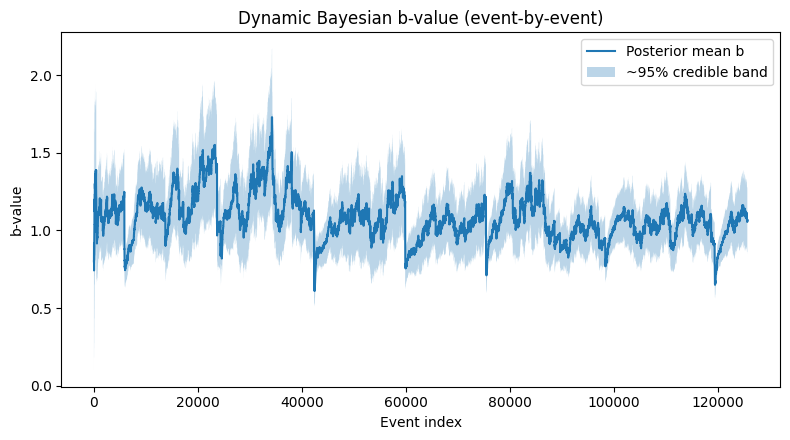

In [3]:
# %%
updater = BayesianGRBUpdater(Mc=3, delta=0.999, a0=5, init_b_target=0.8, mag_key="mag", write_back=True)
results = updater.fit(seq)            # 逐事件更新；同时把结果字段写回0 seq
BayesianGRBUpdater.plot(seq)          # 绘图（可选传入 truth_lines / switch_index）